In [2]:
!python -m pip install pandas numpy scikit-learn seaborn matplotlib statsmodels xgboost imbalanced-learn optuna joblib

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import math 

In [4]:
df1=pd.read_csv("dataset/customers.csv")
df2=pd.read_csv("dataset/bureau_data.csv")
df3=pd.read_csv("dataset/loans.csv")


# merging the datasets

In [5]:
df4=pd.merge(df1,df2,on='cust_id')
df=pd.merge(df4,df3,on='cust_id')

print(df.shape)

df.head()
df.columns

(50000, 33)


Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'loan_id', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default'],
      dtype='object')

## coverting boolean to int

In [6]:
df['default']=df['default'].astype(int)

default_counts=df['default'].value_counts()[1]*100/(df.shape[0])
default_counts


np.float64(8.594)

# implementing train test split here itself just so to avoid the data leakage or else train test contamination

In [7]:
X=df.drop("default",axis=1)
y=df['default']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

df_train=pd.concat([X_train,y_train],axis=1)
df_test=pd.concat([X_test,y_test],axis=1)

print(df_train.shape)
print(df_test.shape)

(37500, 33)
(12500, 33)


<h1 align=center style="color:blue">Data Cleaning</h1>

### lets check for the na values first

In [8]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 48
years_at_current_address        0
city                            0
state                           0
zipcode                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [9]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

## here rather than dropping the values we will try to fill it with the mode of the categorical column

In [10]:
mode_residence=df_train.residence_type.mode()[0]
df_train.fillna({"residence_type":mode_residence},inplace=True)
df_train.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [11]:
mode_residence=df_test.residence_type.mode()[0]
df_test.fillna({"residence_type":mode_residence},inplace=True)
df_test.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

## looking for dup values

In [12]:
df_train.duplicated().sum()

np.int64(0)

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 27434 to 15795
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      37500 non-null  object 
 1   age                          37500 non-null  int64  
 2   gender                       37500 non-null  object 
 3   marital_status               37500 non-null  object 
 4   employment_status            37500 non-null  object 
 5   income                       37500 non-null  int64  
 6   number_of_dependants         37500 non-null  int64  
 7   residence_type               37500 non-null  object 
 8   years_at_current_address     37500 non-null  int64  
 9   city                         37500 non-null  object 
 10  state                        37500 non-null  object 
 11  zipcode                      37500 non-null  int64  
 12  number_of_open_accounts      37500 non-null  int64  
 13  number_of_closed_

In [14]:
numeric_cols=df_train.select_dtypes(["int64"]).columns
categorical_cols = df_train.select_dtypes(include=['object']).columns

print(numeric_cols)
print(categorical_cols)

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'loan_amount', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'default'],
      dtype='object')
Index(['cust_id', 'gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'loan_id', 'loan_purpose',
       'loan_type', 'disbursal_date', 'installment_start_dt'],
      dtype='object')


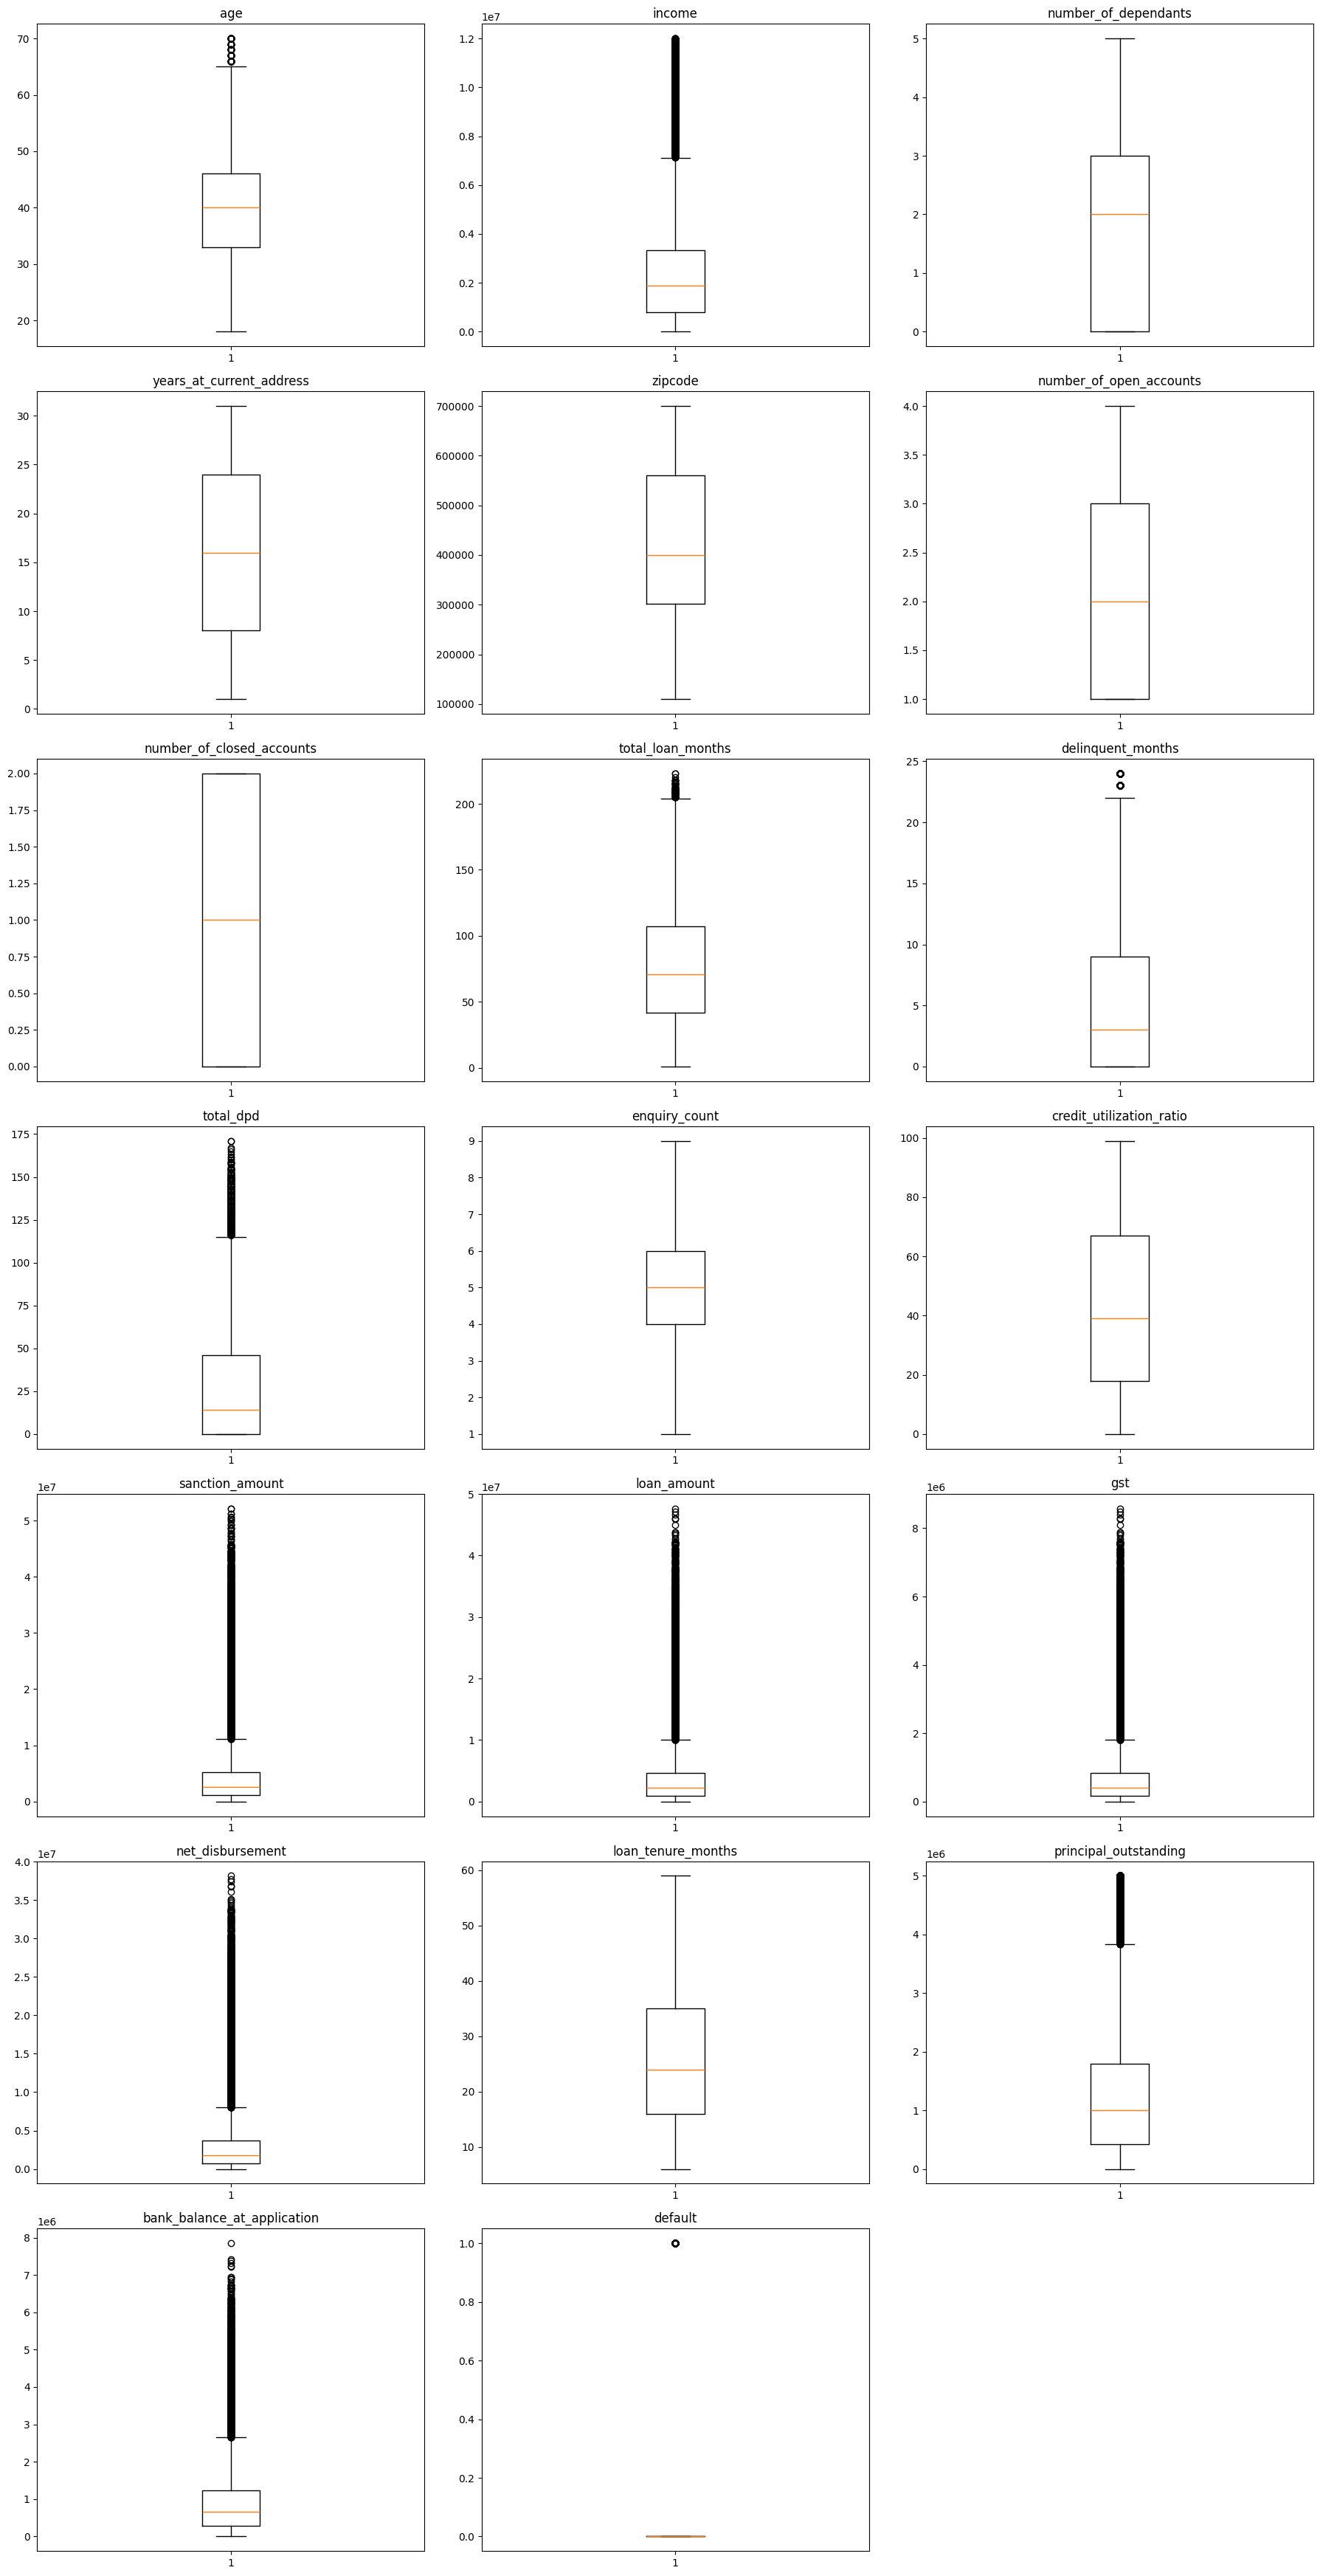

In [15]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df_train[col].dropna())
    plt.title(col)
    plt.tight_layout()

plt.show()

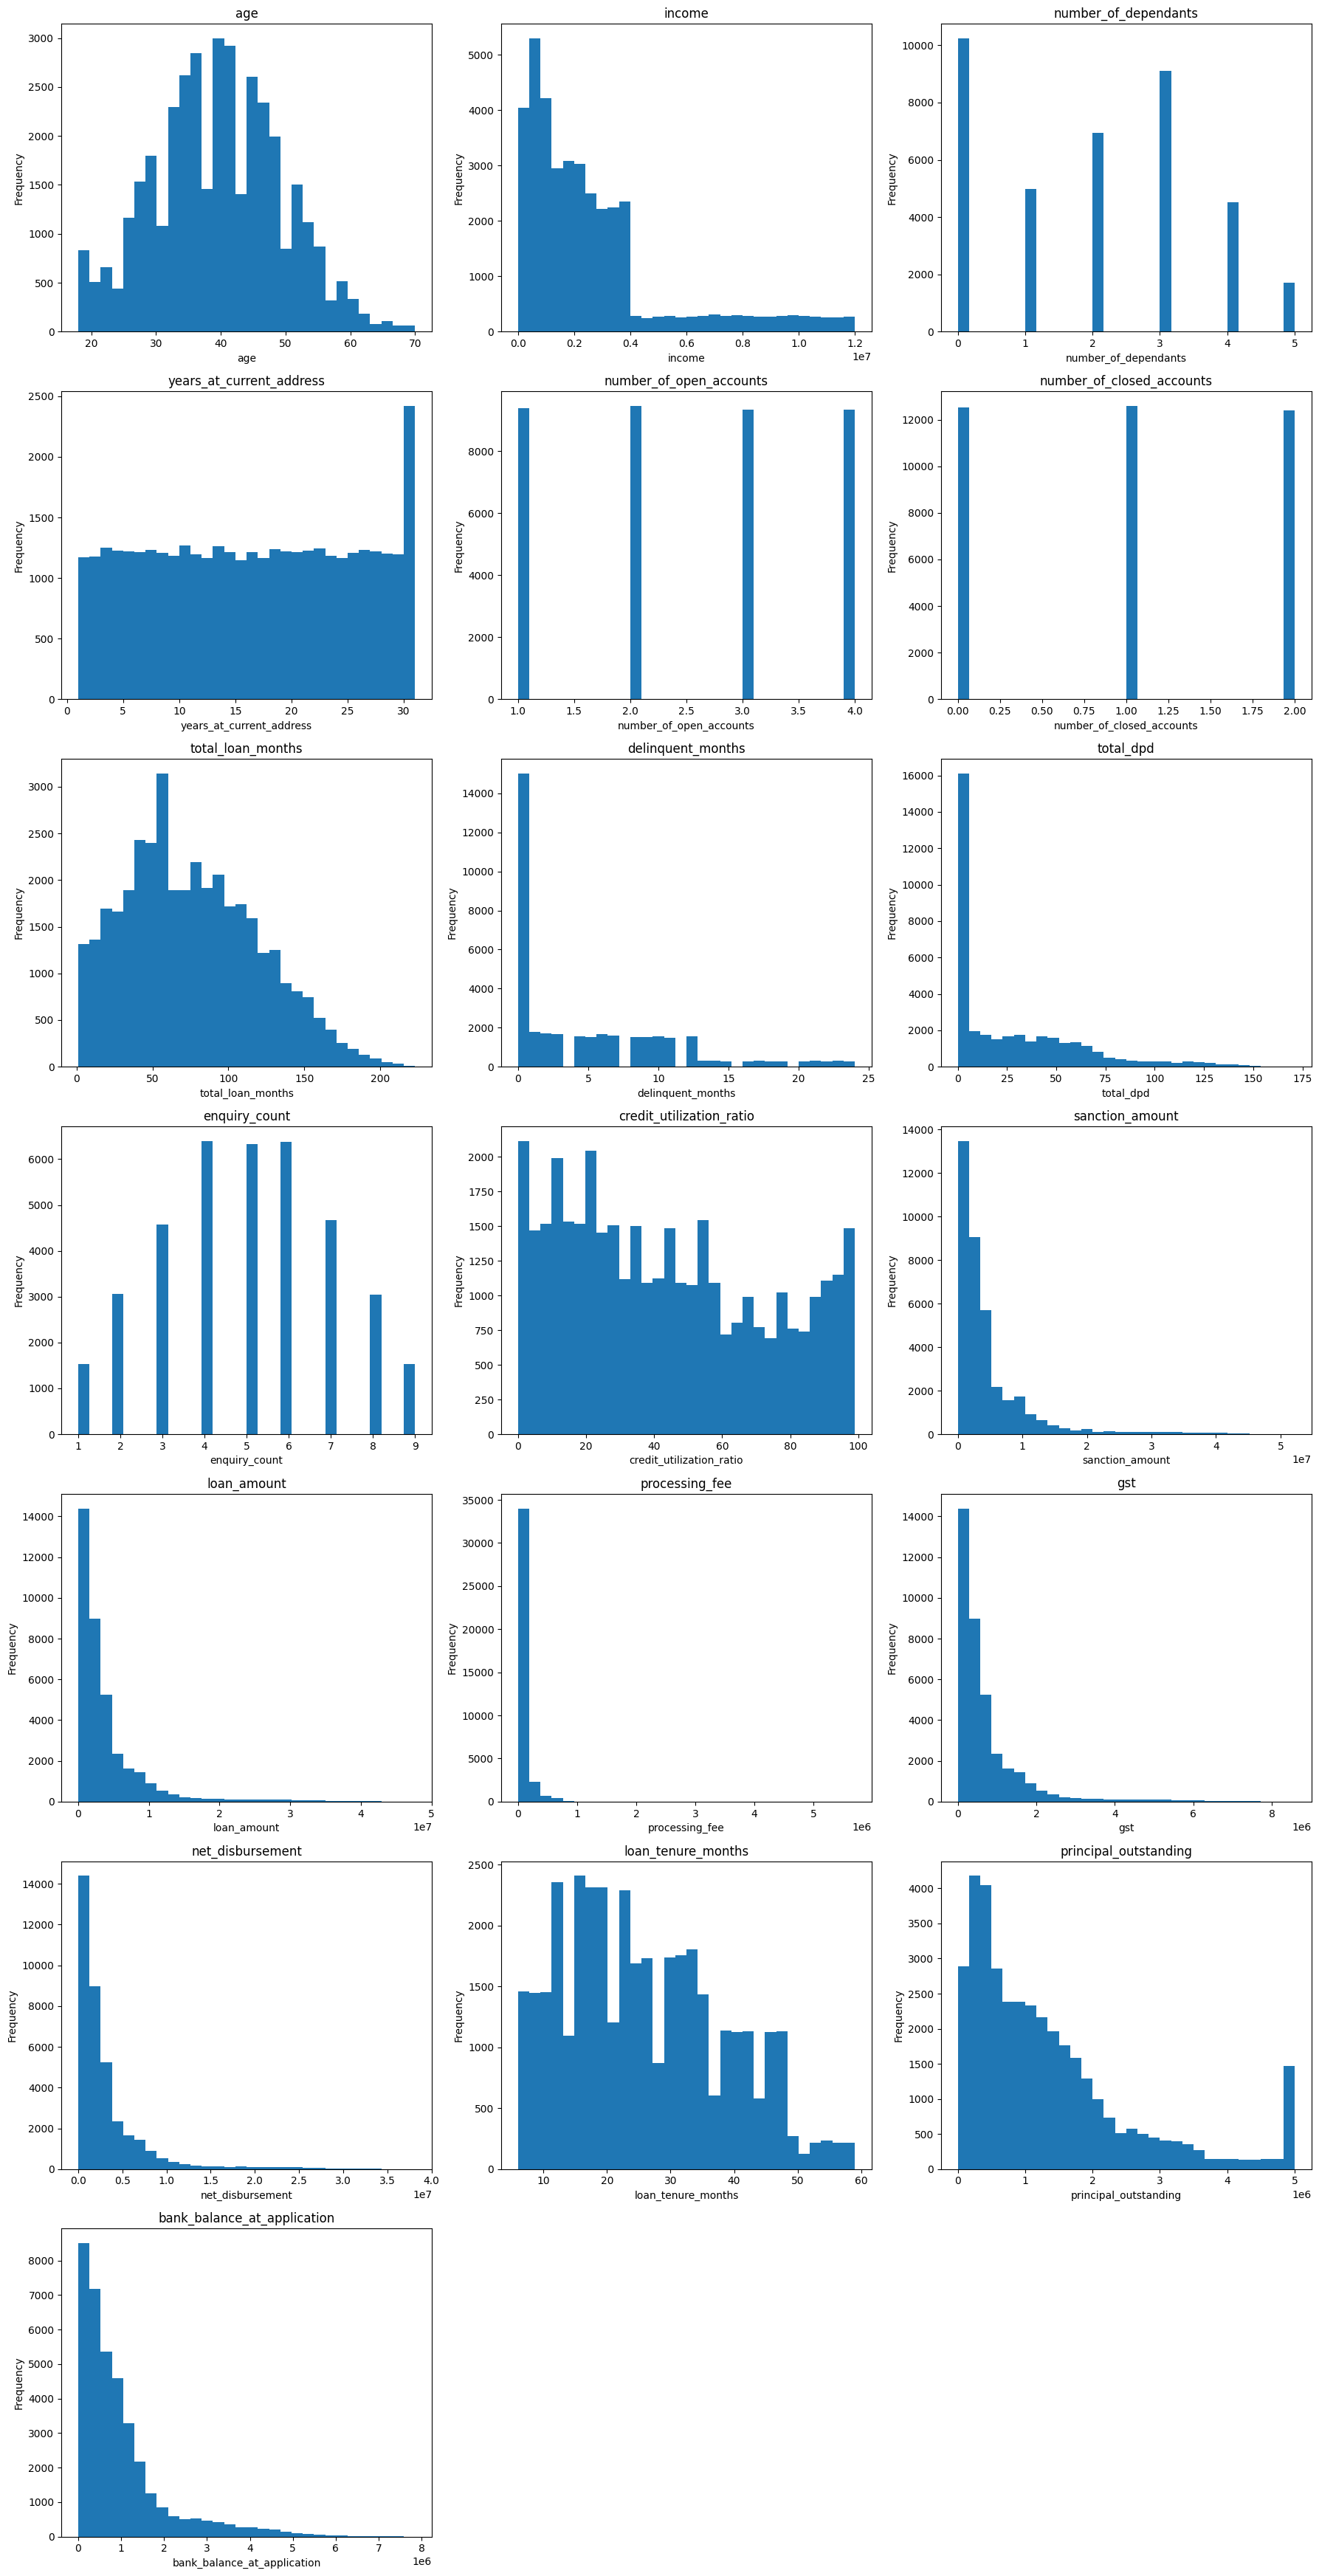

In [16]:
numeric_cols = df_train.select_dtypes(include=["int64", "float64"]).columns

# (optional but recommended)
exclude_cols = ["zipcode", "default"]
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_train[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [17]:
df_train.processing_fee.describe().astype('int64')

count      37500
mean       80724
std       120830
min            0
25%        19180
50%        44700
75%        92000
max      5698029
Name: processing_fee, dtype: int64

## analysing processing free feature

In [18]:
df_train1=df_train[df_train.processing_fee<df_train.loan_amount*0.03]

In [19]:
df_test1=df_test[df_test.processing_fee<df_test.loan_amount*0.03]
df_test1[df_test1.processing_fee>df_test1.loan_amount*0.03]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default


In [20]:
categorical_cols

Index(['cust_id', 'gender', 'marital_status', 'employment_status',
       'residence_type', 'city', 'state', 'loan_id', 'loan_purpose',
       'loan_type', 'disbursal_date', 'installment_start_dt'],
      dtype='object')

In [21]:
categorical_cols1=categorical_cols.drop(['cust_id','loan_id','disbursal_date','installment_start_dt'])

In [22]:
df_train1.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
27434,C27435,45,F,Single,Salaried,1131000,0,Owned,5,Ahmedabad,...,3276000,65520.0,589680,2620800,24,905176,566117,2022-04-21,2022-05-21,0
13400,C13401,29,M,Single,Salaried,2343000,0,Owned,25,Delhi,...,2540000,50800.0,457200,2032000,33,1008916,951329,2020-11-24,2020-12-11,0
883,C00884,50,F,Single,Self-Employed,2891000,0,Mortgage,29,Lucknow,...,1920000,38400.0,345600,1536000,19,1382399,771873,2019-08-25,2019-09-19,0
7303,C07304,43,F,Single,Self-Employed,272000,1,Owned,27,Bangalore,...,298000,5960.0,53640,238400,21,170015,117343,2020-04-16,2020-05-05,0
45124,C45125,31,F,Single,Salaried,141000,0,Owned,27,Jaipur,...,260000,5200.0,46800,208000,45,72025,67719,2024-01-26,2024-02-17,0


In [23]:
for col in categorical_cols1:
    print(col,'--->',df_train1[col].unique().tolist())
print('zipcode','--->',df_train1['zipcode'].unique().tolist())

gender ---> ['F', 'M']
marital_status ---> ['Single', 'Married']
employment_status ---> ['Salaried', 'Self-Employed']
residence_type ---> ['Owned', 'Mortgage', 'Rented']
city ---> ['Ahmedabad', 'Delhi', 'Lucknow', 'Bangalore', 'Jaipur', 'Hyderabad', 'Kolkata', 'Pune', 'Chennai', 'Mumbai']
state ---> ['Gujarat', 'Delhi', 'Uttar Pradesh', 'Karnataka', 'Rajasthan', 'Telangana', 'West Bengal', 'Maharashtra', 'Tamil Nadu']
loan_purpose ---> ['Home', 'Auto', 'Personal', 'Education', 'Personaal']
loan_type ---> ['Secured', 'Unsecured']
zipcode ---> [380001, 110001, 226001, 560001, 302001, 500001, 700001, 411001, 600001, 400001]


# replcing personaal with personal

In [24]:
df_train1['loan_purpose']=df_train1['loan_purpose'].replace({"Personaal":"Personal"})

/tmp/ipykernel_2274785/146964783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train1['loan_purpose']=df_train1['loan_purpose'].replace({"Personaal":"Personal"})


In [25]:
for col in categorical_cols1:
    print(col,'--->',df_train1[col].unique().tolist())
print('zipcode','--->',df_train1['zipcode'].unique().tolist())

gender ---> ['F', 'M']
marital_status ---> ['Single', 'Married']
employment_status ---> ['Salaried', 'Self-Employed']
residence_type ---> ['Owned', 'Mortgage', 'Rented']
city ---> ['Ahmedabad', 'Delhi', 'Lucknow', 'Bangalore', 'Jaipur', 'Hyderabad', 'Kolkata', 'Pune', 'Chennai', 'Mumbai']
state ---> ['Gujarat', 'Delhi', 'Uttar Pradesh', 'Karnataka', 'Rajasthan', 'Telangana', 'West Bengal', 'Maharashtra', 'Tamil Nadu']
loan_purpose ---> ['Home', 'Auto', 'Personal', 'Education']
loan_type ---> ['Secured', 'Unsecured']
zipcode ---> [380001, 110001, 226001, 560001, 302001, 500001, 700001, 411001, 600001, 400001]


In [26]:
df_test1['loan_purpose']=df_test1['loan_purpose'].replace({"Personaal":"Personal"})
df_test1['loan_purpose'].unique().tolist()

/tmp/ipykernel_2274785/3545908706.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test1['loan_purpose']=df_test1['loan_purpose'].replace({"Personaal":"Personal"})


['Education', 'Home', 'Auto', 'Personal']

<h1 align=center style="color:blue">EDA(Exploratory Data Analysis)</h1>

### plotting kde plot for understaing the features wrt the target

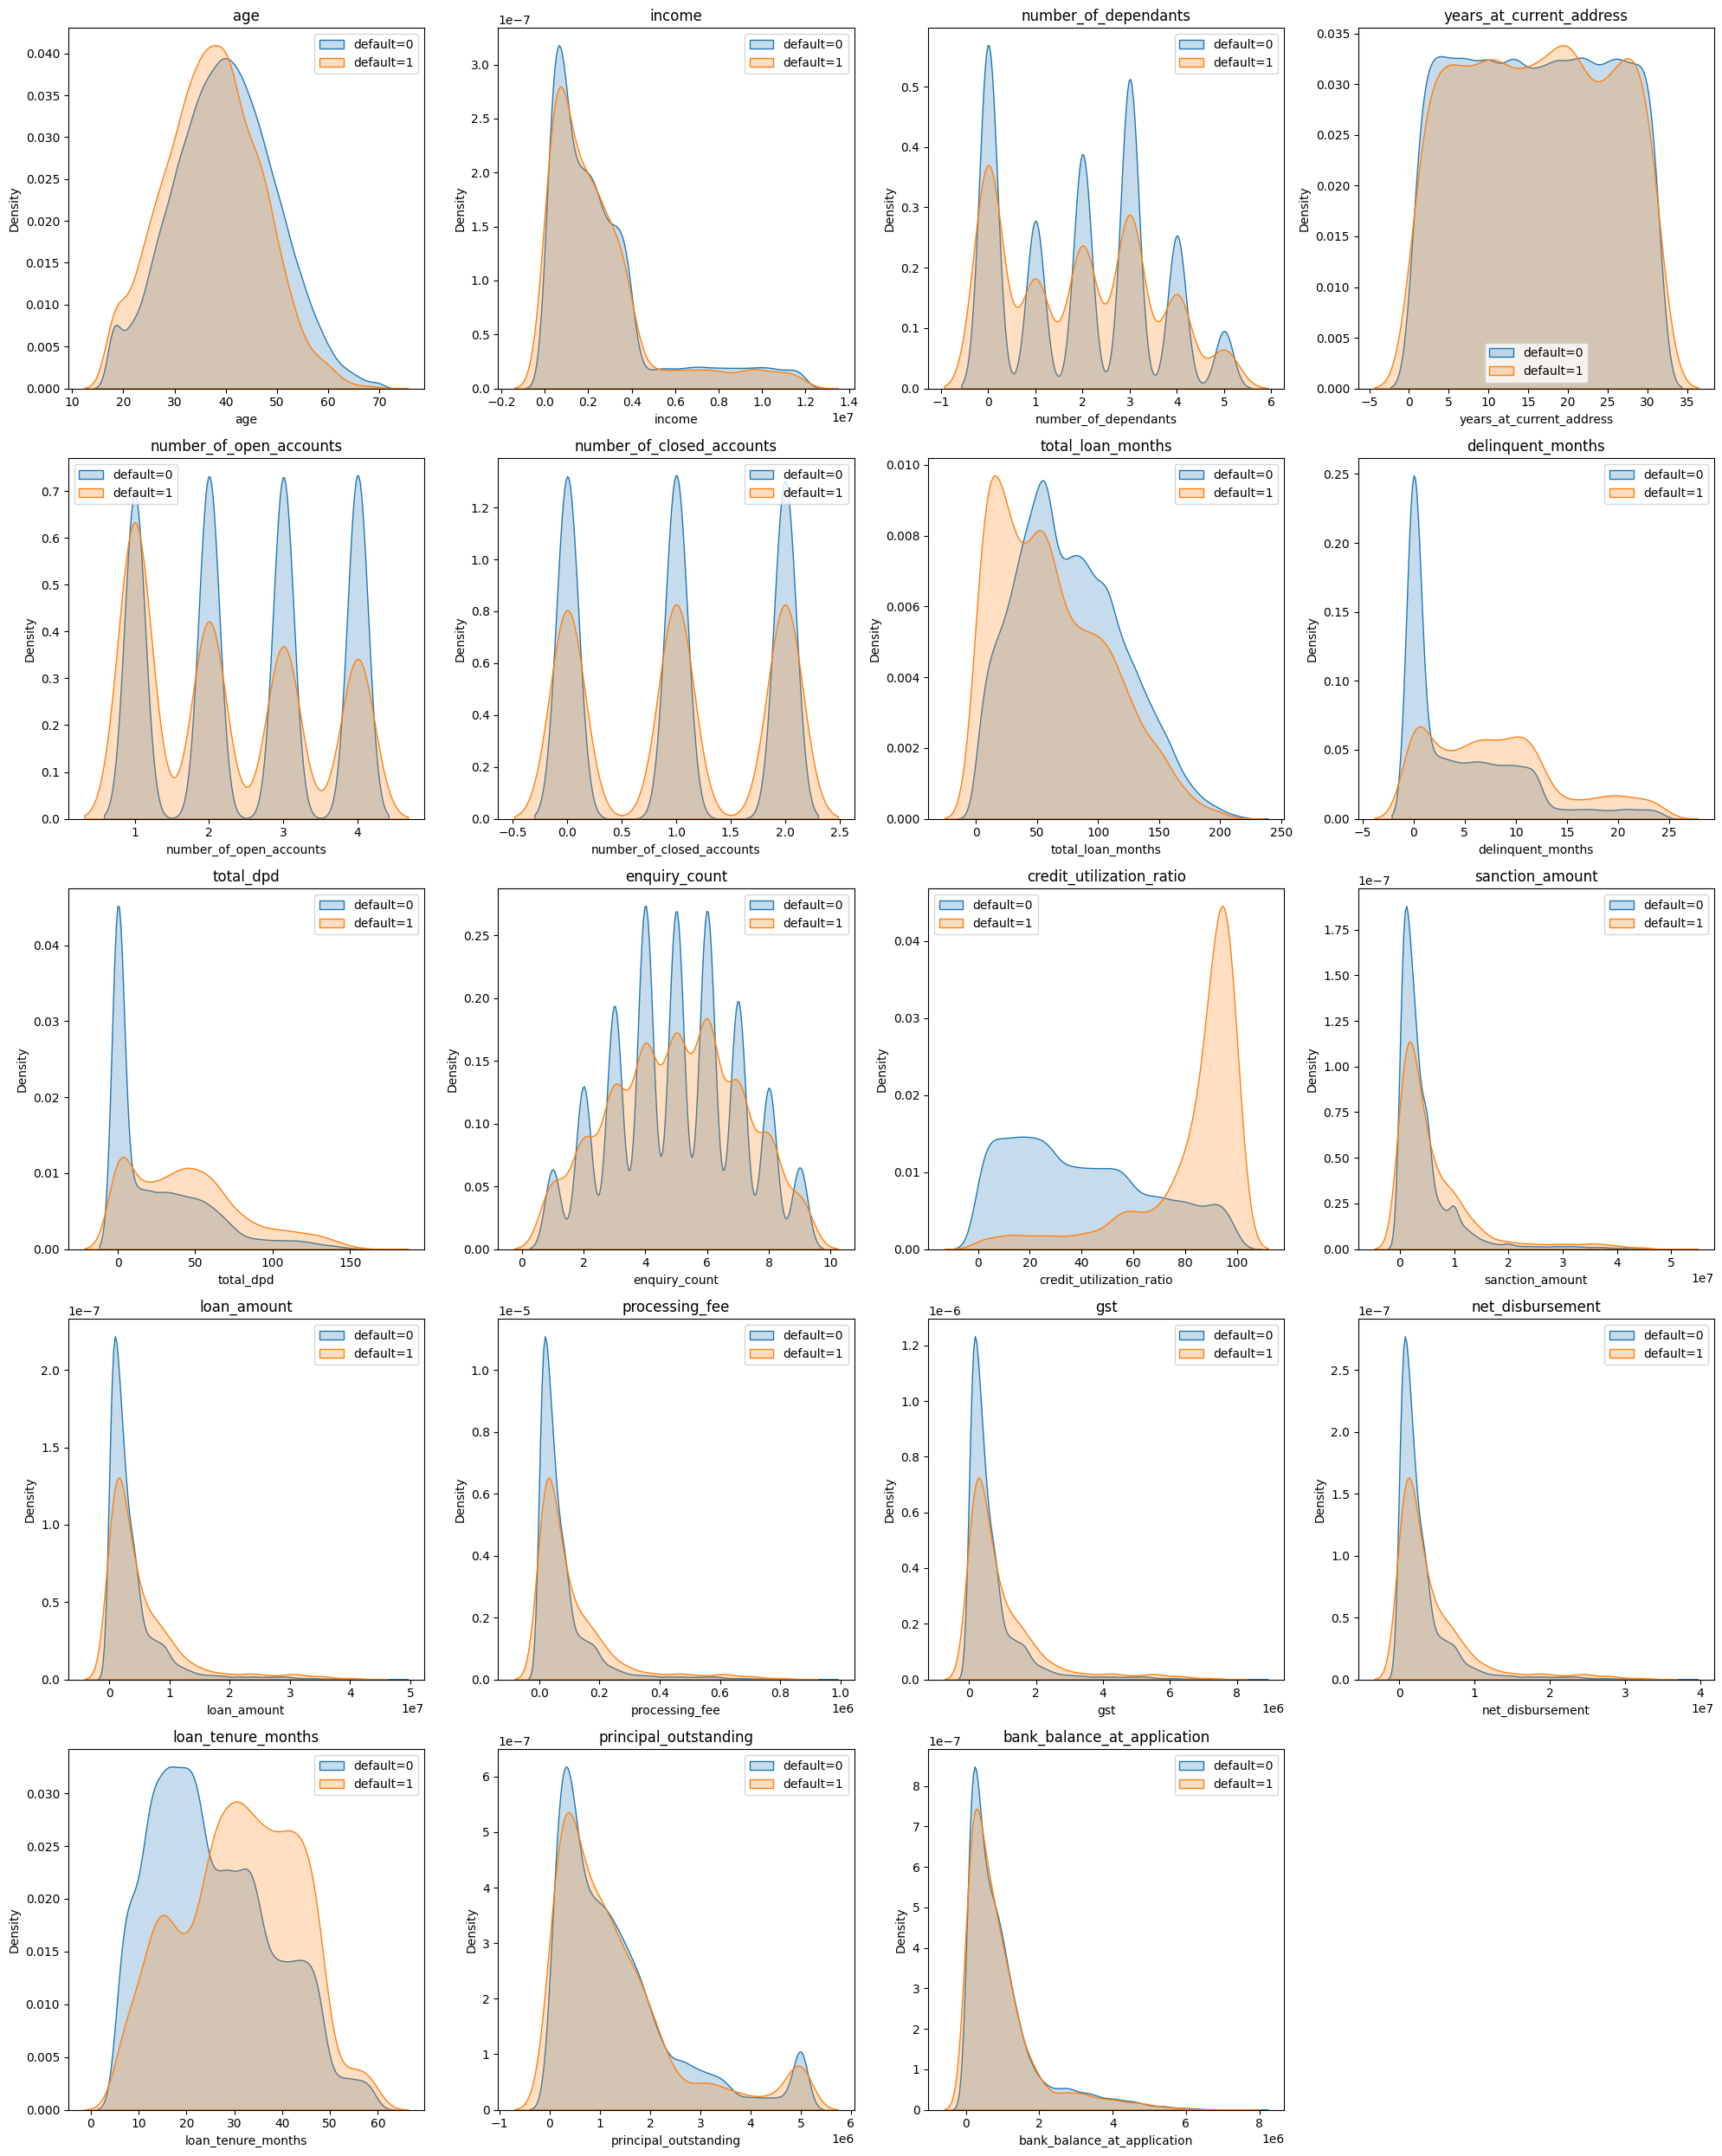

In [27]:

cols = numeric_cols
n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # make indexing easy

for i, col in enumerate(cols):
    sns.kdeplot(
        df_train1[df_train1['default'] == 0][col],
        fill=True,
        label="default=0",
        ax=axes[i]
    )
    sns.kdeplot(
        df_train1[df_train1['default'] == 1][col],
        fill=True,
        label="default=1",
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].legend()

# remove empty plots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Key Insights from KDE Analysis (Strong Predictive Features Only)

### 1. Age
- Borrowers who default tend to be younger compared to non-defaulters.
- Increasing age is associated with lower default risk, indicating greater financial stability among older borrowers.

---

### 2. Income
- Defaulters are concentrated in the lower income ranges.
- Higher income levels are associated with reduced probability of default.

---

### 3. Delinquent Months
- Defaulters show significantly higher delinquent months.
- This feature shows strong separation between default and non-default classes and is a key indicator of repayment behavior.

---

### 4. Total DPD (Days Past Due)
- Total DPD is substantially higher for defaulters.
- Historical payment delays strongly influence default outcomes.

---

### 5. Credit Utilization Ratio
- Defaulters exhibit much higher credit utilization.
- High utilization indicates over-leveraging and is a strong predictor of default risk.

---

### 6. Enquiry Count
- Borrowers with higher enquiry counts are more likely to default.
- Frequent credit enquiries may indicate financial stress or aggressive credit seeking behavior.

---

### 7. Bank Balance at Application
- Non-defaulters tend to have higher bank balances at the time of application.
- Strong liquidity at loan origination reduces default probability.

---

### 8. Principal Outstanding
- Defaulters generally have higher outstanding principal amounts.
- Larger unpaid balances increase repayment pressure and default risk.

---

## Summary
- Behavioral and credit usage variables dominate default prediction.
- Financial stability indicators such as income, age, and bank balance act as protective factors.
- Credit stress indicators (delinquency, utilization, enquiries) are the strongest determinants of default.


<h1 align=center style="color:blue">Feature Engineering</h1>

In [28]:
df_train1['loan_to_income']=round(df_train1['loan_amount']/df_train1['income'],2)
df_train1['loan_to_income'].describe()

/tmp/ipykernel_2274785/3704413536.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train1['loan_to_income']=round(df_train1['loan_amount']/df_train1['income'],2)


count    37487.000000
mean         1.554890
std          0.972907
min          0.300000
25%          0.770000
50%          1.160000
75%          2.450000
max          4.570000
Name: loan_to_income, dtype: float64

In [29]:
df_test1['loan_to_income']=round(df_test1['loan_amount']/df_test1['income'],2)
df_test1['loan_to_income'].describe()

/tmp/ipykernel_2274785/1944647018.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test1['loan_to_income']=round(df_test1['loan_amount']/df_test1['income'],2)


count    12498.000000
mean         1.556737
std          0.968140
min          0.300000
25%          0.770000
50%          1.170000
75%          2.450000
max          4.590000
Name: loan_to_income, dtype: float64

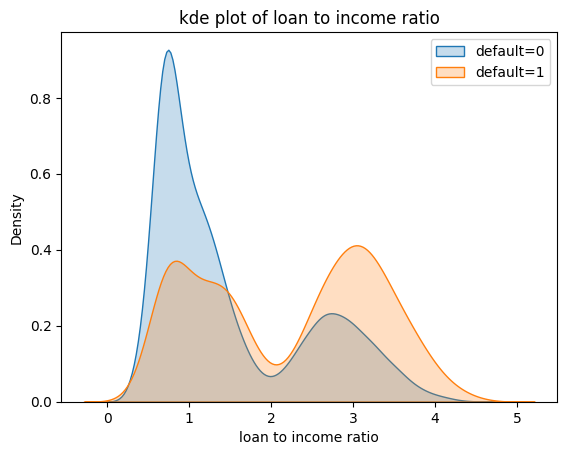

In [30]:
sns.kdeplot(
        df_train1[df_train1['default'] == 0]['loan_to_income'],
        fill=True,
        label="default=0",
    )
sns.kdeplot(
        df_train1[df_train1['default'] == 1]['loan_to_income'],
        fill=True,
        label="default=1",
    )
plt.title("kde plot of loan to income ratio")
plt.xlabel("loan to income ratio")
plt.legend()
plt.show()

In [31]:
df_train1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'loan_id', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default', 'loan_to_income'],
      dtype='object')

In [32]:
df_train1['delinquent_to_loan']=df_train1['delinquent_months']*100/df_train1["total_loan_months"].round(1)
df_train1[['delinquent_months','total_loan_months','delinquent_to_loan']].head(3)

/tmp/ipykernel_2274785/3110953527.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train1['delinquent_to_loan']=df_train1['delinquent_months']*100/df_train1["total_loan_months"].round(1)


,delinquent_months,total_loan_months,delinquent_to_loan
27434,6,90,6.666667
13400,4,119,3.361345
883,14,83,16.867470


In [33]:
df_test1['delinquent_to_loan']=df_test1['delinquent_months']*100/df_test1["total_loan_months"].round(1)
df_test1[['delinquent_months','total_loan_months','delinquent_to_loan']].head(3)

/tmp/ipykernel_2274785/1437575348.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test1['delinquent_to_loan']=df_test1['delinquent_months']*100/df_test1["total_loan_months"].round(1)


,delinquent_months,total_loan_months,delinquent_to_loan
33553,3,70,4.285714
9427,0,115,0.000000
199,0,144,0.000000


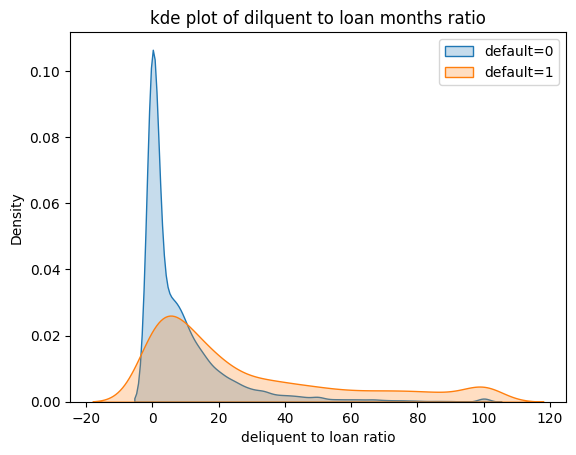

In [34]:
sns.kdeplot(
        df_train1[df_train1['default'] == 0]['delinquent_to_loan'],
        fill=True,
        label="default=0",
    )
sns.kdeplot(
        df_train1[df_train1['default'] == 1]['delinquent_to_loan'],
        fill=True,
        label="default=1",
    )
plt.title("kde plot of dilquent to loan months ratio")
plt.xlabel("deliquent to loan ratio")
plt.legend()
plt.show()

In [35]:
df_train1['avg_dpd_to_deliquency']=np.where(df_train1['delinquent_months']!=0,df_train1['total_dpd']/df_train1['delinquent_months'].round(1),0)
df_train1['avg_dpd_to_deliquency'].describe()

/tmp/ipykernel_2274785/4179675374.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train1['avg_dpd_to_deliquency']=np.where(df_train1['delinquent_months']!=0,df_train1['total_dpd']/df_train1['delinquent_months'].round(1),0)


count    37487.000000
mean         3.294626
std          2.903357
min          0.000000
25%          0.000000
50%          4.333333
75%          5.750000
max         10.000000
Name: avg_dpd_to_deliquency, dtype: float64

In [36]:
df_test1['avg_dpd_to_deliquency']=np.where(df_test1['delinquent_months']!=0,df_test1['total_dpd']/df_test1['delinquent_months'].round(1),0)
df_test1['avg_dpd_to_deliquency'].describe()

/tmp/ipykernel_2274785/3156855430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test1['avg_dpd_to_deliquency']=np.where(df_test1['delinquent_months']!=0,df_test1['total_dpd']/df_test1['delinquent_months'].round(1),0)


count    12498.000000
mean         3.307262
std          2.907380
min          0.000000
25%          0.000000
50%          4.333333
75%          5.747283
max         10.000000
Name: avg_dpd_to_deliquency, dtype: float64

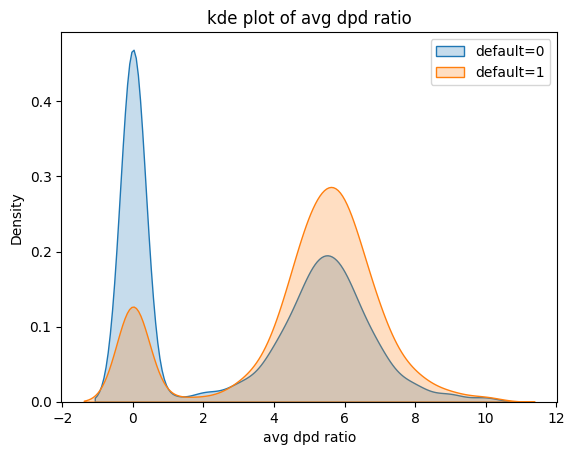

In [37]:
sns.kdeplot(
        df_train1[df_train1['default'] == 0]['avg_dpd_to_deliquency'],
        fill=True,
        label="default=0",
    )
sns.kdeplot(
        df_train1[df_train1['default'] == 1]['avg_dpd_to_deliquency'],
        fill=True,
        label="default=1",
    )
plt.title("kde plot of avg dpd ratio")
plt.xlabel("avg dpd ratio")
plt.legend()
plt.show()

<h1 align=center style="color:blue">Feature Selection</h1>

In [38]:
df_train1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'loan_id', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default', 'loan_to_income', 'delinquent_to_loan',
       'avg_dpd_to_deliquency'],
      dtype='object')

In [39]:
df_train1=df_train1.drop(["cust_id","loan_id"],axis=1)
df_test1=df_test1.drop(["cust_id","loan_id"],axis=1)

In [40]:
df_train1.columns

Index(['age', 'gender', 'marital_status', 'employment_status', 'income',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'default', 'loan_to_income',
       'delinquent_to_loan', 'avg_dpd_to_deliquency'],
      dtype='object')

In [41]:
df_train1=df_train1.drop(['disbursal_date','installment_start_dt','loan_amount','income','total_loan_months','delinquent_months','total_dpd'],axis=1)
df_test1=df_test1.drop(['disbursal_date','installment_start_dt','loan_amount','income','total_loan_months','delinquent_months','total_dpd'],axis=1)

In [42]:
df_train1.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'default', 'loan_to_income',
       'delinquent_to_loan', 'avg_dpd_to_deliquency'],
      dtype='object')

In [43]:
numeric_cols=df_train1.select_dtypes(["int64",'float64']).columns
numeric_cols

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'default', 'loan_to_income',
       'delinquent_to_loan', 'avg_dpd_to_deliquency'],
      dtype='object')

## calculating the vif values

In [44]:
X_train=df_train1.drop('default',axis=1)
y_train=df_train1['default']

cols_to_scale=numeric_cols.drop(['zipcode','default'])

from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

X_train[cols_to_scale]=scaler.fit_transform(X_train[cols_to_scale])
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,loan_to_income,delinquent_to_loan,avg_dpd_to_deliquency
count,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000,37487.000000
mean,0.414681,0.388476,0.499787,418763.450983,0.498795,0.498386,0.500410,0.437656,0.088989,0.083030,0.083030,0.083030,0.375431,0.261931,0.123683,0.293885,0.103945,0.329463
std,0.189510,0.307163,0.297939,168837.508873,0.372407,0.407528,0.252997,0.296517,0.120709,0.113437,0.113437,0.113437,0.234410,0.244515,0.133507,0.227847,0.172685,0.290336
min,0.000000,0.000000,0.000000,110001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,302001.000000,0.000000,0.000000,0.375000,0.181818,0.020440,0.019100,0.019100,0.019100,0.188679,0.078179,0.034088,0.110070,0.000000,0.000000
50%,0.423077,0.400000,0.500000,400001.000000,0.333333,0.500000,0.500000,0.393939,0.049536,0.045887,0.045887,0.045887,0.339623,0.194385,0.082720,0.201405,0.037975,0.433333
75%,0.538462,0.600000,0.766667,560001.000000,0.666667,1.000000,0.625000,0.676768,0.097660,0.095512,0.095512,0.095512,0.547170,0.353152,0.155525,0.503513,0.131148,0.575000
max,1.000000,1.000000,1.000000,700001.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [45]:
X_test=df_test1.drop('default',axis=1)
y_test=df_test1['default']

X_test[cols_to_scale]=scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,loan_to_income,delinquent_to_loan,avg_dpd_to_deliquency
count,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000,12498.000000
mean,0.413678,0.386174,0.503088,420098.055529,0.503681,0.506961,0.503471,0.439030,0.088840,0.082764,0.082764,0.082764,0.378690,0.263201,0.124546,0.294318,0.104143,0.330726
std,0.189011,0.306940,0.296372,169419.472823,0.374460,0.405600,0.255602,0.296583,0.119051,0.111372,0.111372,0.111372,0.235128,0.245299,0.134018,0.226731,0.173989,0.290738
min,0.000000,0.000000,0.000000,110001.000000,0.000000,0.000000,0.000000,0.000000,0.000019,0.000126,0.000126,0.000126,0.000000,-0.000163,0.000216,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,302001.000000,0.000000,0.000000,0.375000,0.181818,0.021208,0.019725,0.019725,0.019725,0.188679,0.078853,0.034518,0.110070,0.000000,0.000000
50%,0.423077,0.400000,0.500000,411001.000000,0.666667,0.500000,0.500000,0.393939,0.049871,0.046244,0.046244,0.046244,0.358491,0.195309,0.083575,0.203747,0.037736,0.433333
75%,0.538462,0.600000,0.766667,560001.000000,1.000000,1.000000,0.750000,0.676768,0.099138,0.096693,0.096693,0.096693,0.547170,0.354632,0.156611,0.503513,0.129032,0.574728
max,1.000000,1.000000,1.000000,700001.000000,1.000000,1.000000,1.000000,1.000000,0.951002,1.003192,1.003192,1.003192,1.000000,1.000000,0.879450,1.004684,1.000000,1.000000


In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df['variable']=data.columns
    vif_df['VIF']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [47]:
calculate_vif(X_train[cols_to_scale])


/home/anjan/mlp-2/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variable,VIF
0,age,5.583329
1,number_of_dependants,2.722930
2,years_at_current_address,3.361643
3,number_of_open_accounts,4.345435
4,number_of_closed_accounts,2.341637
5,enquiry_count,6.319958
6,credit_utilization_ratio,2.891095
7,sanction_amount,102.151608
8,processing_fee,inf
9,gst,inf


In [48]:
features_to_drop=['sanction_amount','processing_fee','gst','net_disbursement','principal_outstanding']
X_train=X_train.drop(features_to_drop,axis=1)

In [49]:
numeric_cols=X_train.select_dtypes(["int64",'float64']).columns
numeric_cols


vif_df=calculate_vif(X_train[numeric_cols])
vif_df

,variable,VIF
0,age,5.547281
1,number_of_dependants,2.733647
2,years_at_current_address,3.449705
3,zipcode,5.596402
4,number_of_open_accounts,4.325335
5,number_of_closed_accounts,2.365621
6,enquiry_count,6.422742
7,credit_utilization_ratio,2.942059
8,loan_tenure_months,5.992030
9,bank_balance_at_application,1.806712


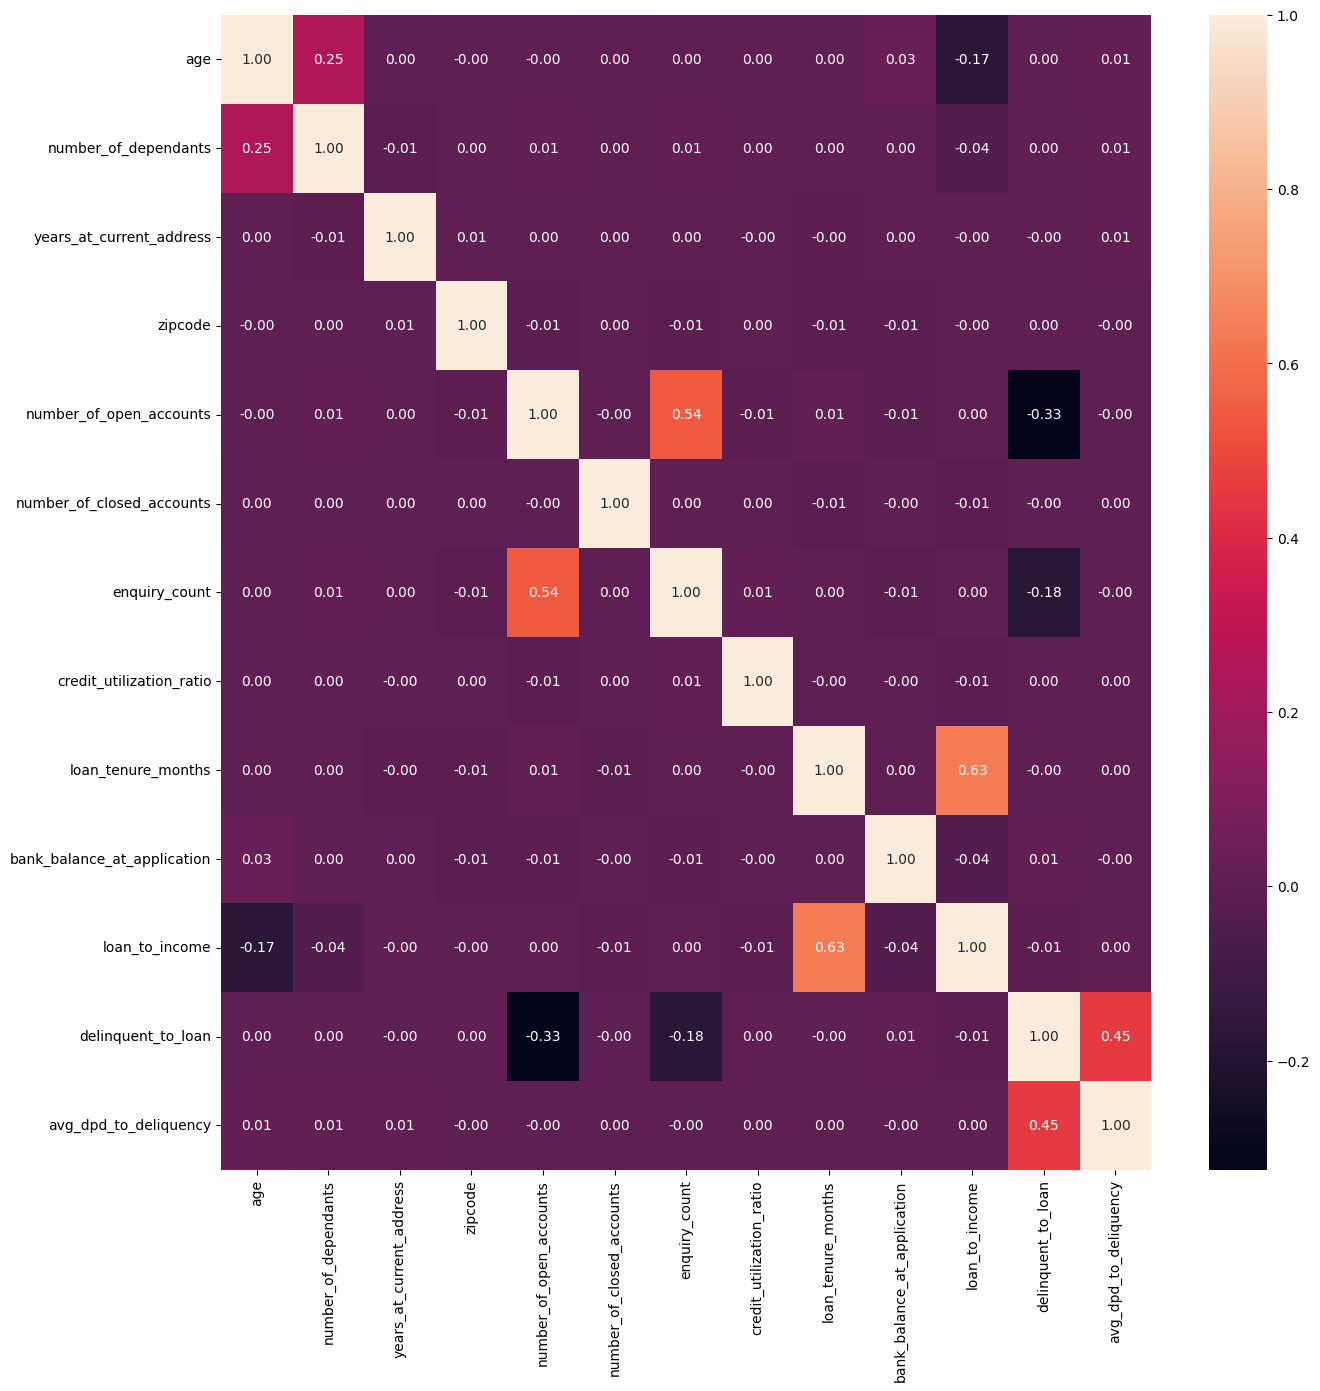

In [50]:
plt.figure(figsize=(15,15))
sns.heatmap(X_train[numeric_cols].corr(),annot=True,fmt='.2f')
plt.show()

<h2 align=center style="color:blue">WOE(weight of evidence) AND IV(information value) formula</h2>

<img src="ivwoe.png" alt="infopic"></img>

## calculation of the iv and the woe values of all the features

In [51]:
temp=pd.concat([X_train,y_train],axis=1)
temp.groupby('loan_purpose')['default'].agg(['count','sum'])


,count,sum
loan_purpose,,
Auto,7437,314
Education,5626,546
Home,11271,1744
Personal,13153,585


In [52]:
def caluculate_woe_iv(df,feature,target):
    grouped=df.groupby(feature)[target].agg(['count','sum'])
    grouped=grouped.rename(columns={'count':'total','sum':'good'})
    grouped['bad']=grouped['total']-grouped['good']
   
    sum_good=grouped['good'].sum()
    sum_bad=grouped['bad'].sum()
    grouped['good_pct']=grouped['good']/sum_good
    grouped['bad_pct']=grouped['bad']/sum_bad
    grouped['woe']=np.log(grouped['good_pct']/grouped['bad_pct'])
    grouped['iv']=grouped['woe']*(grouped['good_pct']-grouped['bad_pct'])

    grouped['woe']=grouped['woe'].replace([np.inf,-np.inf],0)
    grouped['iv']=grouped['iv'].replace([np.inf,-np.inf],0)
     
    total_iv=grouped['iv'].sum() 

    return grouped,total_iv



grouped,total_iv=caluculate_woe_iv(pd.concat([X_train,y_train],axis=1),'loan_purpose','default')
total_iv

np.float64(0.39377543144164784)

In [53]:
X_train.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_purpose', 'loan_type',
       'loan_tenure_months', 'bank_balance_at_application', 'loan_to_income',
       'delinquent_to_loan', 'avg_dpd_to_deliquency'],
      dtype='object')

In [54]:
iv_features={}

for feature in X_train.columns:
    if X_train[feature].dtype=='object':
        _,iv=caluculate_woe_iv(pd.concat([X_train,y_train],axis=1),feature,'default')
        iv_features[feature]=float(iv)
    else:
        X_binned=pd.cut(X_train[feature],bins=10,labels=False)
        _,iv=caluculate_woe_iv(pd.concat([X_binned,y_train],axis=1),feature,'default')
        iv_features[feature]=float(iv)
iv_features

{'age': 0.07592687127752061,
 'gender': 0.000482276463421216,
 'marital_status': 0.002196681370832318,
 'employment_status': 0.002447818101774487,
 'number_of_dependants': 0.00364589452118596,
 'residence_type': 0.2594019617563985,
 'years_at_current_address': 0.001042536380353028,
 'city': 0.000817870465334103,
 'state': 0.0007881984519711978,
 'zipcode': 0.0007436024782513755,
 'number_of_open_accounts': 0.07324250836253295,
 'number_of_closed_accounts': 0.00026280824021760536,
 'enquiry_count': 0.005484982638303533,
 'credit_utilization_ratio': 2.4228228499400095,
 'loan_purpose': 0.39377543144164784,
 'loan_type': 0.17304705897793143,
 'loan_tenure_months': 0.23450610202970526,
 'bank_balance_at_application': 0.004242001247914226,
 'loan_to_income': 0.4915664145044282,
 'delinquent_to_loan': 0.678322540101926,
 'avg_dpd_to_deliquency': 0.42123646562822287}

In [55]:
iv_values=pd.DataFrame(list(iv_features.items()),columns=["Feature","iv"])
iv_values=iv_values.sort_values(by="iv",ascending=False)
iv_values

,Feature,iv
13,credit_utilization_ratio,2.422823
19,delinquent_to_loan,0.678323
18,loan_to_income,0.491566
20,avg_dpd_to_deliquency,0.421236
14,loan_purpose,0.393775
5,residence_type,0.259402
16,loan_tenure_months,0.234506
15,loan_type,0.173047
0,age,0.075927
10,number_of_open_accounts,0.073243


In [56]:
final_features=[feature for feature,iv in iv_features.items() if iv>0.02]
final_features

['age',
 'residence_type',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'loan_to_income',
 'delinquent_to_loan',
 'avg_dpd_to_deliquency']

<h2 align=center style="color:blue">Feature Encoding</h2>

In [57]:
X_train_reduced=X_train[final_features]
X_test_reduced=X_test[final_features]

In [58]:
X_train_encoded=pd.get_dummies(X_train_reduced,drop_first=True)
X_test_encoded=pd.get_dummies(X_test_reduced,drop_first=True)

X_train_encoded.head()

,age,number_of_open_accounts,credit_utilization_ratio,loan_tenure_months,loan_to_income,delinquent_to_loan,avg_dpd_to_deliquency,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
27434,0.519231,1.000000,0.595960,0.339623,0.608899,0.066667,0.550000,True,False,False,True,False,False
13400,0.211538,0.666667,0.929293,0.509434,0.182670,0.033613,0.425000,True,False,False,False,False,False
883,0.615385,0.333333,0.838384,0.245283,0.084309,0.168675,0.557143,False,False,False,False,True,True
7303,0.480769,0.000000,0.343434,0.283019,0.187354,0.000000,0.000000,True,False,False,False,False,False
45124,0.250000,0.333333,0.191919,0.735849,0.360656,0.096774,0.466667,True,False,True,False,False,False


<h2 align=center style="color:blue">Model Training</h2>

### training Logistic Regression,RandomForest,XGB without the class imbalance

In [59]:
y_train.value_counts()

default
0    34298
1     3189
Name: count, dtype: int64

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model=LogisticRegression()
model.fit(X_train_encoded,y_train)

y_pred=model.predict(X_test_encoded)

report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.69      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [61]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(X_train_encoded,y_train)

y_pred=model.predict(X_test_encoded)

report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.84      0.69      0.76      1108

    accuracy                           0.96     12498
   macro avg       0.91      0.84      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [62]:
from xgboost import XGBClassifier

model=XGBClassifier()
model.fit(X_train_encoded,y_train)

y_pred=model.predict(X_test_encoded)

report=classification_report(y_test,y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.97      0.98      0.98     11390
           1       0.82      0.73      0.77      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.86      0.87     12498
weighted avg       0.96      0.96      0.96     12498



### performing randomized serach cv on the  linear regression and the xgb

In [63]:
from sklearn.model_selection import RandomizedSearchCV

# Model (no deprecated params)
log_reg = LogisticRegression(
    solver="saga",
    max_iter=2000
)

# Hyperparameter space (modern & valid)
param_dist_lr = {
    "C": np.logspace(-4, 4, 20),
    "l1_ratio": np.linspace(0, 1, 6),   # 0=L2, 1=L1
    "class_weight": [None, "balanced"]
}

random_search_lr = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist_lr,
    n_iter=30,
    scoring="f1",        # use f1_weighted if multiclass
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=1
)

# Fit
random_search_lr.fit(X_train_encoded, y_train)

# Predict
y_pred_lr = random_search_lr.predict(X_test_encoded)

# Classification Report
print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11390
           1       0.83      0.71      0.77      1108

    accuracy                           0.96     12498
   macro avg       0.90      0.85      0.87     12498
weighted avg       0.96      0.96      0.96     12498



In [64]:

# xgb = XGBClassifier(
#     objective="binary:logistic",
#     eval_metric="logloss",
#     tree_method="hist",
#     n_jobs=-1
# )

# param_dist_xgb = {
#     "n_estimators": [200, 300, 500],
#     "max_depth": [3, 4, 6, 8],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "subsample": [0.7, 0.8, 1.0],
#     "colsample_bytree": [0.7, 0.8, 1.0],
#     "gamma": [0, 0.1, 0.2],
#     "reg_alpha": [0, 0.1, 1],
#     "reg_lambda": [1, 1.5, 2]
# }

# random_search_xgb = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_dist_xgb,
#     n_iter=30,
#     scoring="f1",
#     cv=5,
#     random_state=42,
#     n_jobs=1,
#     verbose=1
# )

# random_search_xgb.fit(X_train_encoded, y_train)

# y_pred_xgb = random_search_xgb.predict(X_test_encoded)

# print("XGBoost Classification Report:\n")
# print(classification_report(y_test, y_pred_xgb))


## undersampling

In [65]:
from imblearn.under_sampling import RandomUnderSampler

rus=RandomUnderSampler(random_state=42)

X_train_rus,y_train_rus=rus.fit_resample(X_train_encoded,y_train)
y_train_rus.value_counts()

default
0    3189
1    3189
Name: count, dtype: int64

### training logistic and xgb on the new data

In [66]:
model=LogisticRegression()
model.fit(X_train_rus,y_train_rus)

y_pred=model.predict(X_test_encoded)
report=classification_report(y_test,y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     11390
           1       0.53      0.95      0.68      1108

    accuracy                           0.92     12498
   macro avg       0.76      0.93      0.82     12498
weighted avg       0.95      0.92      0.93     12498



In [67]:
model=XGBClassifier()
model.fit(X_train_rus,y_train_rus)

y_pred=model.predict(X_test_encoded)

report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.95      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.84     12498
weighted avg       0.96      0.93      0.94     12498



## smote tomek

In [68]:
from imblearn.combine import SMOTETomek

smot=SMOTETomek(random_state=42)

X_train_smt,y_train_smt=smot.fit_resample(X_train_encoded,y_train)
y_train_smt.value_counts()

default
0    34225
1    34225
Name: count, dtype: int64

## logistic and xgb

In [69]:
model=LogisticRegression()
model.fit(X_train_smt,y_train_smt)

y_pred=model.predict(X_test_encoded)
report=classification_report(y_test,y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.57      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.83     12498
weighted avg       0.96      0.93      0.94     12498



In [70]:
model=XGBClassifier()
model.fit(X_train_smt,y_train_smt)

y_pred=model.predict(X_test_encoded)

report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11390
           1       0.75      0.82      0.79      1108

    accuracy                           0.96     12498
   macro avg       0.87      0.90      0.88     12498
weighted avg       0.96      0.96      0.96     12498



<h2 align=center style="color:blue">Model finetuning using Optuna</h2>

In [71]:
import optuna
from sklearn.metrics import f1_score,make_scorer
from sklearn.model_selection import cross_val_score

/home/anjan/mlp-2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [72]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

[I 2026-02-22 18:42:52,765] A new study created in memory with name: no-name-13ea104e-7e3c-4b42-ac00-e94cfe4b9cce
[I 2026-02-22 18:42:54,363] Trial 0 finished with value: 0.9444519779732868 and parameters: {'C': 0.6556036811891578, 'solver': 'saga', 'tol': 7.749295838950547e-05, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9444519779732868.
[I 2026-02-22 18:42:55,592] Trial 1 finished with value: 0.9449229918195426 and parameters: {'C': 134.6641419104254, 'solver': 'newton-cg', 'tol': 0.0007989827915271528, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9449229918195426.
[I 2026-02-22 18:42:56,801] Trial 2 finished with value: 0.9449808093205726 and parameters: {'C': 3568.208128790511, 'solver': 'saga', 'tol': 0.00754377249238559, 'class_weight': None}. Best is trial 2 with value: 0.9449808093205726.
[I 2026-02-22 18:42:58,210] Trial 3 finished with value: 0.9442906027959537 and parameters: {'C': 0.5740858296319397, 'solver': 'saga', 'tol': 6.426051162427253e-

In [73]:
study_logistic.best_trial

FrozenTrial(number=46, state=<TrialState.COMPLETE: 1>, values=[0.9451400403848069], datetime_start=datetime.datetime(2026, 2, 22, 18, 43, 6, 132227), datetime_complete=datetime.datetime(2026, 2, 22, 18, 43, 6, 303510), params={'C': 23.02912732283961, 'solver': 'liblinear', 'tol': 0.01060999351453105, 'class_weight': 'balanced'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'C': FloatDistribution(high=10000.0, log=True, low=0.0001, step=None), 'solver': CategoricalDistribution(choices=('lbfgs', 'liblinear', 'saga', 'newton-cg')), 'tol': FloatDistribution(high=0.1, log=True, low=1e-06, step=None), 'class_weight': CategoricalDistribution(choices=(None, 'balanced'))}, trial_id=46, value=None)

In [74]:
print("Best Trial")
trial=study_logistic.best_trial
print(f"the macro f1 score is:{format(trial.value)}")
print("params")
for key, value in trial.params.items():
    print(f"       {key}:{value}")
    
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_logistic.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best Trial
the macro f1 score is:0.9451400403848069
params
       C:23.02912732283961
       solver:liblinear
       tol:0.01060999351453105
       class_weight:balanced
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.56      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.83     12498
weighted avg       0.96      0.93      0.94     12498



### Attempt 4

1. XGBoost
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [75]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param,n_jobs=1)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=1)
    
    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-02-22 18:43:06,950] A new study created in memory with name: no-name-dbed4fe4-2fb5-47f6-8159-618565196d65
[I 2026-02-22 18:43:07,932] Trial 0 finished with value: 0.962598480287488 and parameters: {'lambda': 0.008470948880653443, 'alpha': 0.001946471395491936, 'subsample': 0.922485682830913, 'colsample_bytree': 0.8257026022097442, 'max_depth': 6, 'eta': 0.21124182627242785, 'gamma': 5.996088548409817, 'scale_pos_weight': 9.81667456016156, 'min_child_weight': 1, 'max_delta_step': 9}. Best is trial 0 with value: 0.962598480287488.
[I 2026-02-22 18:43:08,970] Trial 1 finished with value: 0.9538791902661684 and parameters: {'lambda': 0.006950924062799774, 'alpha': 0.008343195293515652, 'subsample': 0.6053717921183547, 'colsample_bytree': 0.5047423106961825, 'max_depth': 6, 'eta': 0.10051814626468591, 'gamma': 9.296708759998753, 'scale_pos_weight': 3.4795530588482166, 'min_child_weight': 8, 'max_delta_step': 10}. Best is trial 0 with value: 0.962598480287488.
[I 2026-02-22 18:43:09,

In [76]:
print('Best trial:')
trial = study_xgb.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print(f"   {key}:{value}")
    
best_params = study_xgb.best_params
best_model_xgb = XGBClassifier(**best_params)
best_model_xgb.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_xgb.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.975888974913303
  Params: 
   lambda:0.003367633229749303
   alpha:0.177324506494861
   subsample:0.7509904233922814
   colsample_bytree:0.8299421629060086
   max_depth:9
   eta:0.16256924324824382
   gamma:0.5190545481076276
   scale_pos_weight:1.5439235721996767
   min_child_weight:6
   max_delta_step:2
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     11390
           1       0.72      0.86      0.78      1108

    accuracy                           0.96     12498
   macro avg       0.85      0.91      0.88     12498
weighted avg       0.96      0.96      0.96     12498



In [77]:
y_pred=best_model_logistic.predict(X_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11390
           1       0.56      0.94      0.71      1108

    accuracy                           0.93     12498
   macro avg       0.78      0.94      0.83     12498
weighted avg       0.96      0.93      0.94     12498



In [78]:
from sklearn.metrics import roc_curve

probabilites=best_model_logistic.predict_proba(X_test_encoded)[:,1]
probabilites

fpr, tpr, thresholds = roc_curve(y_test, probabilites)
fpr[:10],thresholds[:10]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.77963126e-05,
        8.77963126e-05, 1.75592625e-04, 1.75592625e-04, 2.63388938e-04,
        2.63388938e-04, 3.51185250e-04]),
 array([       inf, 0.99999976, 0.99803527, 0.9980112 , 0.9973006 ,
        0.99726797, 0.99610946, 0.99610942, 0.99522155, 0.99509021]))

In [79]:
from sklearn.metrics import auc

area=auc(fpr,tpr)
area

0.9829953280951369

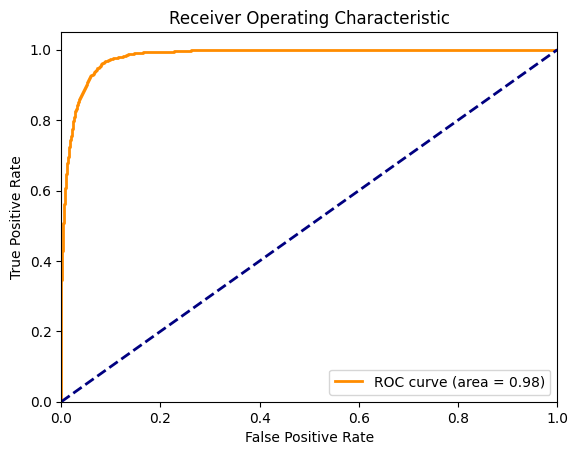

In [80]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

<h2 align=center style="color:blue">checking the performance of the model using rank ordering and ks statistic</h2>

In [81]:
probabilites=best_model_logistic.predict_proba(X_test_encoded)[:,1]

df_ks=pd.DataFrame({
     "default truth":y_test,
     "default probability":probabilites,
})

df_ks=df_ks.sort_values("default probability",ascending=False)
df_ks

,default truth,default probability
2907,1,9.999998e-01
1661,1,9.999998e-01
2949,1,9.999993e-01
15711,1,9.999991e-01
35448,1,9.999990e-01
...,...,...
16256,0,1.984247e-08
12038,0,1.670193e-08
18778,0,1.643056e-08
34278,0,1.290413e-08


In [82]:
df_ks['decile']=pd.qcut(df_ks['default probability'],10,labels=False,duplicates='drop')
df_ks

,default truth,default probability,decile
2907,1,9.999998e-01,9
1661,1,9.999998e-01,9
2949,1,9.999993e-01,9
15711,1,9.999991e-01,9
35448,1,9.999990e-01,9
...,...,...,...
16256,0,1.984247e-08,0
12038,0,1.670193e-08,0
18778,0,1.643056e-08,0
34278,0,1.290413e-08,0


In [83]:
df_grouped_ks=df_ks.groupby('decile').apply(lambda x:pd.Series({
        'Minimum Probability':x['default probability'].min(),
        'Maximum Probability':x['default probability'].max(),
        'Events':x['default truth'].sum(),
        'Non Events':x['default truth'].count()-x['default truth'].sum(),      
}))
df_grouped_ks.reset_index(inplace=True)
df_grouped_ks.head()

/tmp/ipykernel_2274785/2223816541.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped_ks=df_ks.groupby('decile').apply(lambda x:pd.Series({


,decile,Minimum Probability,Maximum Probability,Events,Non Events
0,0,6.346808e-09,0.000003,0.0,1250.0
1,1,2.933103e-06,0.000019,0.0,1250.0
2,2,1.906423e-05,0.000087,0.0,1250.0
3,3,8.737463e-05,0.000391,0.0,1249.0
4,4,3.918228e-04,0.001704,0.0,1250.0


In [84]:
df_grouped_ks['Event Rate']=df_grouped_ks['Events']*100/(df_grouped_ks['Events']+df_grouped_ks['Non Events'])
df_grouped_ks['Non Event Rate']=df_grouped_ks['Non Events']*100/(df_grouped_ks['Events']+df_grouped_ks['Non Events'])
df_grouped_ks.head()

,decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate
0,0,6.346808e-09,0.000003,0.0,1250.0,0.0,100.0
1,1,2.933103e-06,0.000019,0.0,1250.0,0.0,100.0
2,2,1.906423e-05,0.000087,0.0,1250.0,0.0,100.0
3,3,8.737463e-05,0.000391,0.0,1249.0,0.0,100.0
4,4,3.918228e-04,0.001704,0.0,1250.0,0.0,100.0


In [85]:
df_grouped_ks=df_grouped_ks.sort_values('decile',ascending=False)
df_grouped_ks

,decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate
9,9,8.087406e-01,1.000000,917.0,333.0,73.360000,26.640000
8,8,2.353954e-01,0.808408,169.0,1081.0,13.520000,86.480000
7,7,4.398768e-02,0.235261,18.0,1232.0,1.440000,98.560000
6,6,8.247525e-03,0.043967,3.0,1246.0,0.240192,99.759808
5,5,1.707522e-03,0.008230,1.0,1249.0,0.080000,99.920000
4,4,3.918228e-04,0.001704,0.0,1250.0,0.000000,100.000000
3,3,8.737463e-05,0.000391,0.0,1249.0,0.000000,100.000000
2,2,1.906423e-05,0.000087,0.0,1250.0,0.000000,100.000000
1,1,2.933103e-06,0.000019,0.0,1250.0,0.000000,100.000000
0,0,6.346808e-09,0.000003,0.0,1250.0,0.000000,100.000000


In [86]:
df_grouped_ks['Cum Events'] =  df_grouped_ks['Events'].cumsum()
df_grouped_ks['Cum Non-events'] =  df_grouped_ks['Non Events'].cumsum()
df_grouped_ks

,decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate,Cum Events,Cum Non-events
9,9,8.087406e-01,1.000000,917.0,333.0,73.360000,26.640000,917.0,333.0
8,8,2.353954e-01,0.808408,169.0,1081.0,13.520000,86.480000,1086.0,1414.0
7,7,4.398768e-02,0.235261,18.0,1232.0,1.440000,98.560000,1104.0,2646.0
6,6,8.247525e-03,0.043967,3.0,1246.0,0.240192,99.759808,1107.0,3892.0
5,5,1.707522e-03,0.008230,1.0,1249.0,0.080000,99.920000,1108.0,5141.0
4,4,3.918228e-04,0.001704,0.0,1250.0,0.000000,100.000000,1108.0,6391.0
3,3,8.737463e-05,0.000391,0.0,1249.0,0.000000,100.000000,1108.0,7640.0
2,2,1.906423e-05,0.000087,0.0,1250.0,0.000000,100.000000,1108.0,8890.0
1,1,2.933103e-06,0.000019,0.0,1250.0,0.000000,100.000000,1108.0,10140.0
0,0,6.346808e-09,0.000003,0.0,1250.0,0.000000,100.000000,1108.0,11390.0


In [87]:
df_grouped_ks['Cum Event Rate'] = df_grouped_ks['Cum Events'] * 100 / df_grouped_ks['Events'].sum()
df_grouped_ks['Cum Non event Rate'] = df_grouped_ks['Cum Non-events']*100 / df_grouped_ks['Non Events'].sum()
df_grouped_ks

,decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non event Rate
9,9,8.087406e-01,1.000000,917.0,333.0,73.360000,26.640000,917.0,333.0,82.761733,2.923617
8,8,2.353954e-01,0.808408,169.0,1081.0,13.520000,86.480000,1086.0,1414.0,98.014440,12.414399
7,7,4.398768e-02,0.235261,18.0,1232.0,1.440000,98.560000,1104.0,2646.0,99.638989,23.230904
6,6,8.247525e-03,0.043967,3.0,1246.0,0.240192,99.759808,1107.0,3892.0,99.909747,34.170325
5,5,1.707522e-03,0.008230,1.0,1249.0,0.080000,99.920000,1108.0,5141.0,100.000000,45.136084
4,4,3.918228e-04,0.001704,0.0,1250.0,0.000000,100.000000,1108.0,6391.0,100.000000,56.110623
3,3,8.737463e-05,0.000391,0.0,1249.0,0.000000,100.000000,1108.0,7640.0,100.000000,67.076383
2,2,1.906423e-05,0.000087,0.0,1250.0,0.000000,100.000000,1108.0,8890.0,100.000000,78.050922
1,1,2.933103e-06,0.000019,0.0,1250.0,0.000000,100.000000,1108.0,10140.0,100.000000,89.025461
0,0,6.346808e-09,0.000003,0.0,1250.0,0.000000,100.000000,1108.0,11390.0,100.000000,100.000000


In [88]:
df_grouped_ks['ks']=abs(df_grouped_ks['Cum Event Rate']-df_grouped_ks['Cum Non event Rate'])
df_grouped_ks

,decile,Minimum Probability,Maximum Probability,Events,Non Events,Event Rate,Non Event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non event Rate,ks
9,9,8.087406e-01,1.000000,917.0,333.0,73.360000,26.640000,917.0,333.0,82.761733,2.923617,79.838116
8,8,2.353954e-01,0.808408,169.0,1081.0,13.520000,86.480000,1086.0,1414.0,98.014440,12.414399,85.600042
7,7,4.398768e-02,0.235261,18.0,1232.0,1.440000,98.560000,1104.0,2646.0,99.638989,23.230904,76.408085
6,6,8.247525e-03,0.043967,3.0,1246.0,0.240192,99.759808,1107.0,3892.0,99.909747,34.170325,65.739422
5,5,1.707522e-03,0.008230,1.0,1249.0,0.080000,99.920000,1108.0,5141.0,100.000000,45.136084,54.863916
4,4,3.918228e-04,0.001704,0.0,1250.0,0.000000,100.000000,1108.0,6391.0,100.000000,56.110623,43.889377
3,3,8.737463e-05,0.000391,0.0,1249.0,0.000000,100.000000,1108.0,7640.0,100.000000,67.076383,32.923617
2,2,1.906423e-05,0.000087,0.0,1250.0,0.000000,100.000000,1108.0,8890.0,100.000000,78.050922,21.949078
1,1,2.933103e-06,0.000019,0.0,1250.0,0.000000,100.000000,1108.0,10140.0,100.000000,89.025461,10.974539
0,0,6.346808e-09,0.000003,0.0,1250.0,0.000000,100.000000,1108.0,11390.0,100.000000,100.000000,0.000000


<img src="ksstats.png"></img>

# 📊 Decile Analysis & Model Performance Assessment

To assess whether rank ordering is followed, we examine whether higher deciles (with higher predicted probabilities) have higher event rates compared to lower deciles. Proper rank ordering means that as we move from the top decile (9) to the bottom decile (0), the event rate should consistently decrease.

In this context:

- **Events** → Bad customers (defaults)  
- **Non-Events** → Good customers (non-defaults)  

---

## 🔎 Insights from the Decile Table

### 1️⃣ Top Deciles (Strong Risk Concentration)

**Decile 9**
- Event Rate: **73.36%**
- Non-Event Rate: 26.64%
- Cumulative Event Rate: **82.76%**
- KS: **79.84%**
- This decile captures the majority of defaulters, indicating strong model separation at the top risk band.

**Decile 8**
- Event Rate: **13.60%**
- Cumulative Event Rate: **98.10%**
- KS: **85.70%** (Highest)
- The model achieves maximum separation here, indicating optimal discrimination at this cutoff.

---

### 2️⃣ Middle Deciles (Declining Risk)

**Deciles 7 & 6**
- Event Rates drop sharply to **1.44%** and **0.16%**
- Cumulative Event Rate approaches ~100%
- KS begins to decline from its peak
- Indicates proper rank ordering as risk decreases significantly.

---

### 3️⃣ Lower Deciles (Low/No Risk)

**Deciles 5 to 0**
- Event Rate: **0%**
- Non-Event Rate: 100%
- These deciles contain only non-defaulters.
- Model confidently identifies low-risk customers.

---

## 📈 KS Statistic Interpretation

- Maximum KS = **85.70%** (at Decile 8)
- Indicates very strong discriminatory power.
- Since KS > 40% and occurs within top deciles, the model is considered highly predictive.

---

## ✅ Overall Conclusion

- Proper rank ordering is maintained.
- Event rate decreases consistently from top to bottom deciles.
- High KS value indicates strong separation between defaulters and non-defaulters.
- Model demonstrates excellent discriminatory performance.


In [89]:
gini_coefficient=2*area-1
gini_coefficient,area

(0.9659906561902738, 0.9829953280951369)

AUC of 0.98: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.96: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.

The Gini coefficient ranges from -1 to 1, where a value closer to 1 signifies a perfect model, 0 indicates a model with no discriminative power, and -1 signifies a perfectly incorrect model.

<h2 align=center style="color:blue">checking the performance of the model using rank ordering and ks statistic</h2>

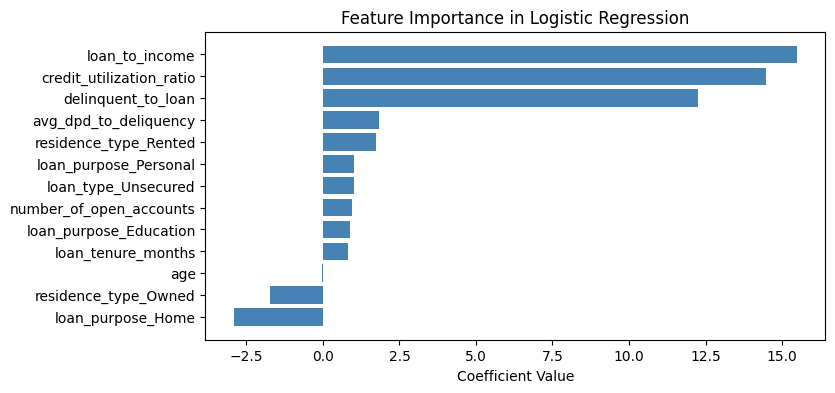

In [90]:
final_model=best_model_logistic

feature_importance=final_model.coef_[0]

df_features=pd.DataFrame(feature_importance,index=X_train_encoded.columns,columns=['Coefficients'])
df_features=df_features.sort_values('Coefficients',ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(df_features.index, df_features['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [91]:
X_train_encoded.columns

Index(['age', 'number_of_open_accounts', 'credit_utilization_ratio',
       'loan_tenure_months', 'loan_to_income', 'delinquent_to_loan',
       'avg_dpd_to_deliquency', 'residence_type_Owned',
       'residence_type_Rented', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'loan_type_Unsecured'],
      dtype='object')

In [92]:
from joblib import dump

model={
    "model":final_model,
    "features":X_train_encoded.columns,
    "scaler":scaler,
    "cols_to_scale":cols_to_scale
}


dump(model,"artifacts/model_data.joblib")


['artifacts/model_data.joblib']